# **Miami Housing Market Insights: Predicting Housing Prices with Machine Learning**

**Introduction**
- 

The Miami housing market is a dynamic and complex environment influenced by a wide range of factors, including property characteristics, location, and market trends. This project focuses on analyzing Miami housing market data to uncover key insights and predict property sale prices using machine learning models. By leveraging linear regression as a baseline model and XGBoost as an advanced model, the goal is to develop a robust predictive framework that can accurately estimate property prices.

Accurate predictions of housing prices have significant business implications. For real estate professionals, such models can help identify under- or overvalued properties, enabling more informed pricing strategies and investment decisions. Developers and policymakers can also benefit from understanding how property features and location influence prices, which can guide urban planning and resource allocation. For buyers and sellers, these insights provide clarity on market trends and fair valuation, ultimately fostering more efficient transactions.

By starting with linear regression, a simple and interpretable approach, the project establishes a baseline for comparison. XGBoost, as an advanced model, accounts for complex, non-linear relationships and feature interactions, providing a more sophisticated understanding of the factors driving property prices. Through this analysis, the project aims to deliver actionable insights and tools to navigate the Miami real estate market effectively.

In [39]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA  
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [40]:
df = pd.read_csv('/Users/mychalortiz/Downloads/DataScienceProjects/MiamiHousingDataAnalysis/Data/miami-housing.csv')

Importing libraries/packages and storing data in a DataFrame

**Data Dictionary**
- 
PARCELNO: unique identifier for each property. About 1% appear multiple times.

SALE_PRC: sale price ($)

LND_SQFOOT: land area (square feet)

TOT_LVG_AREA: floor area (square feet)

SPEC_FEAT_VAL: value of special features (e.g., swimming pools) ($)

RAIL_DIST: distance to the nearest rail line (an indicator of noise) (feet)

OCEAN_DIST: distance to the ocean (feet)

WATER_DIST: distance to the nearest body of water (feet)

CNTR_DIST: distance to the Miami central business district (feet)

SUBCNTR_DI: distance to the nearest subcenter (feet)

HWY_DIST: distance to the nearest highway (an indicator of noise) (feet)

age: age of the structure

avno60plus: dummy variable for airplane noise exceeding an acceptable level

structure_quality: quality of the structure

month_sold: sale month in 2016 (1 = jan)

LATITUDE

LONGITUDE

**Exploratory Data Analysis**
- 

In [41]:
df.head(10)

,LATITUDE,LONGITUDE,PARCELNO,SALE_PRC,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality
0,25.891031,-80.160561,622280070620,440000.0,9375,1753,0,2815.9,12811.4,347.6,42815.3,37742.2,15954.9,67,0,8,4
1,25.891324,-80.153968,622280100460,349000.0,9375,1715,0,4359.1,10648.4,337.8,43504.9,37340.5,18125.0,63,0,9,4
2,25.891334,-80.153740,622280100470,800000.0,9375,2276,49206,4412.9,10574.1,297.1,43530.4,37328.7,18200.5,61,0,2,4
3,25.891765,-80.152657,622280100530,988000.0,12450,2058,10033,4585.0,10156.5,0.0,43797.5,37423.2,18514.4,63,0,9,4
4,25.891825,-80.154639,622280100200,755000.0,12800,1684,16681,4063.4,10836.8,326.6,43599.7,37550.8,17903.4,42,0,7,4
5,25.892060,-80.161354,622280070180,630000.0,9900,1531,2978,2391.4,13017.0,188.9,43135.1,38176.2,15687.2,41,0,2,4
6,25.892473,-80.157217,622280080100,1020000.0,10387,1753,23116,3277.4,11667.8,0.0,43598.7,37973.9,17068.2,63,0,2,5
7,25.893019,-80.157426,622280080400,850000.0,10272,1663,34933,3112.4,11718.1,10.5,43780.8,38198.3,16989.9,21,0,9,4
8,25.893046,-80.161556,622280080020,250000.0,9375,1493,11668,2081.8,13043.8,51.5,43481.7,38542.0,15623.3,56,0,3,4
9,25.893050,-80.158048,622280080370,1220000.0,13803,3077,34580,2937.7,11917.7,9.7,43730.1,38235.2,16787.0,63,0,11,5


Explain features

In [42]:
df.shape

(13932, 17)

13,932 rows and 17 columns

**Feature Engineering**
- 

In [44]:
df['Suburban'] = df['CNTR_DIST'] > 26400
#defining home as being suburban if it is more than 26400 feet (5 miles)

df['Suburban'] = df['Suburban'].astype(int)
#converting 'suburban' from boolean to integer

df['Land_Utilization'] = df['LND_SQFOOT'] / df['TOT_LVG_AREA']
#determining how much land is utilized by dividing land area by floor area


df.head(5)



,LATITUDE,LONGITUDE,PARCELNO,SALE_PRC,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality,Suburban,Land_Utilization
0,25.891031,-80.160561,622280070620,440000.0,9375,1753,0,2815.9,12811.4,347.6,42815.3,37742.2,15954.9,67,0,8,4,1,5.347975
1,25.891324,-80.153968,622280100460,349000.0,9375,1715,0,4359.1,10648.4,337.8,43504.9,37340.5,18125.0,63,0,9,4,1,5.466472
2,25.891334,-80.153740,622280100470,800000.0,9375,2276,49206,4412.9,10574.1,297.1,43530.4,37328.7,18200.5,61,0,2,4,1,4.119069
3,25.891765,-80.152657,622280100530,988000.0,12450,2058,10033,4585.0,10156.5,0.0,43797.5,37423.2,18514.4,63,0,9,4,1,6.049563
4,25.891825,-80.154639,622280100200,755000.0,12800,1684,16681,4063.4,10836.8,326.6,43599.7,37550.8,17903.4,42,0,7,4,1,7.600950


Creating 'Suburban' feature, defining homes within 5 miles as being urban. Also Creating 'Land_Utilization' feature, determining how much land is utilized by dividing land area by floor area.

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` wi

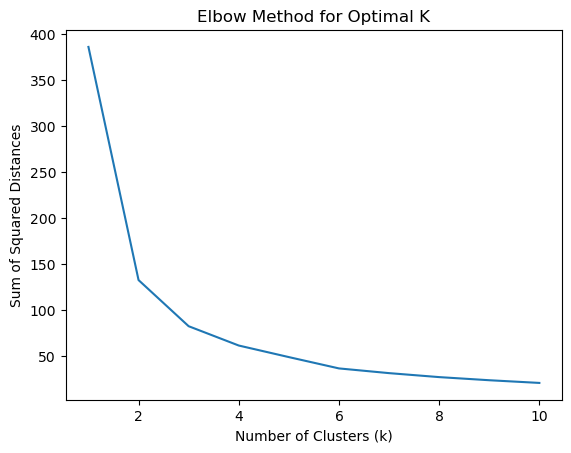

In [45]:
coordinates = df[['LATITUDE', 'LONGITUDE']]
#getting latitude and longitude 

inertia = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(coordinates)
    inertia.append(kmeans.inertia_)
#using elbow method to determine optimal number of clusters

plt.plot(k_values, inertia)
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances')
plt.show()
#plotting elbow curve

Using k-means clustering to cluster neighborhoods together. Based on the elbow method, the optimal number of clusters is 3. However, being that Miami is a city with many distinct neighborhoods (with distinct housing markets), 10 clusters will be used.

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


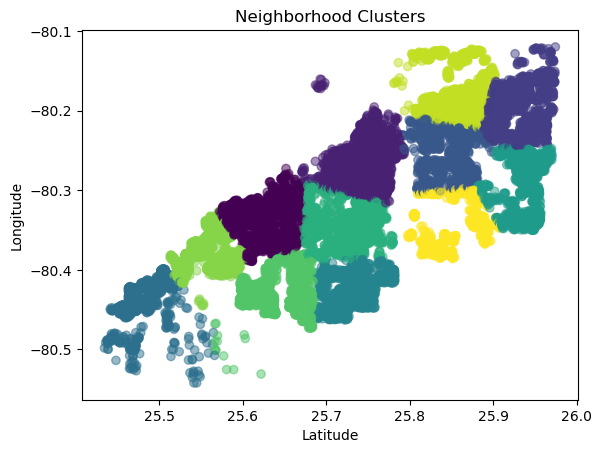

In [46]:
numClusters = 12
kmeans = KMeans(n_clusters = numClusters, random_state=42)
df['Neighborhood'] = kmeans.fit_predict(coordinates)
#fitting the model and assigning neighborhood cluster to homes

plt.scatter(coordinates['LATITUDE'], coordinates['LONGITUDE'], c=df['Neighborhood'], cmap='viridis', alpha=0.5)
plt.title('Neighborhood Clusters')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()
#plotting neighborhoods

The neighborhoods are generally clustered well, capturing distinct areas. For example, we see the greater Brickell area clustered together, just south of Wynwood/North Miami. While aligning clusters precisely with neighborhood boundaries would be ideal, it presents significant challenges being that we would rely solely on latitude and longitude. Doing so could be explored in the future, however. For now, the current clusters provide sufficient differentiation to provide insights for the model.

In [47]:
df.head(5)

,LATITUDE,LONGITUDE,PARCELNO,SALE_PRC,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality,Suburban,Land_Utilization,Neighborhood
0,25.891031,-80.160561,622280070620,440000.0,9375,1753,0,2815.9,12811.4,347.6,42815.3,37742.2,15954.9,67,0,8,4,1,5.347975,10
1,25.891324,-80.153968,622280100460,349000.0,9375,1715,0,4359.1,10648.4,337.8,43504.9,37340.5,18125.0,63,0,9,4,1,5.466472,10
2,25.891334,-80.153740,622280100470,800000.0,9375,2276,49206,4412.9,10574.1,297.1,43530.4,37328.7,18200.5,61,0,2,4,1,4.119069,10
3,25.891765,-80.152657,622280100530,988000.0,12450,2058,10033,4585.0,10156.5,0.0,43797.5,37423.2,18514.4,63,0,9,4,1,6.049563,10
4,25.891825,-80.154639,622280100200,755000.0,12800,1684,16681,4063.4,10836.8,326.6,43599.7,37550.8,17903.4,42,0,7,4,1,7.600950,10


Previewing dataset to view changes.

**Exploratory Data Analysis (Continued)**
- 

In [48]:
df.isnull().sum()

LATITUDE             0
LONGITUDE            0
PARCELNO             0
SALE_PRC             0
LND_SQFOOT           0
TOT_LVG_AREA         0
SPEC_FEAT_VAL        0
RAIL_DIST            0
OCEAN_DIST           0
WATER_DIST           0
CNTR_DIST            0
SUBCNTR_DI           0
HWY_DIST             0
age                  0
avno60plus           0
month_sold           0
structure_quality    0
Suburban             0
Land_Utilization     0
Neighborhood         0
dtype: int64

No null values

In [49]:
df.duplicated().sum()

0

No duplicates

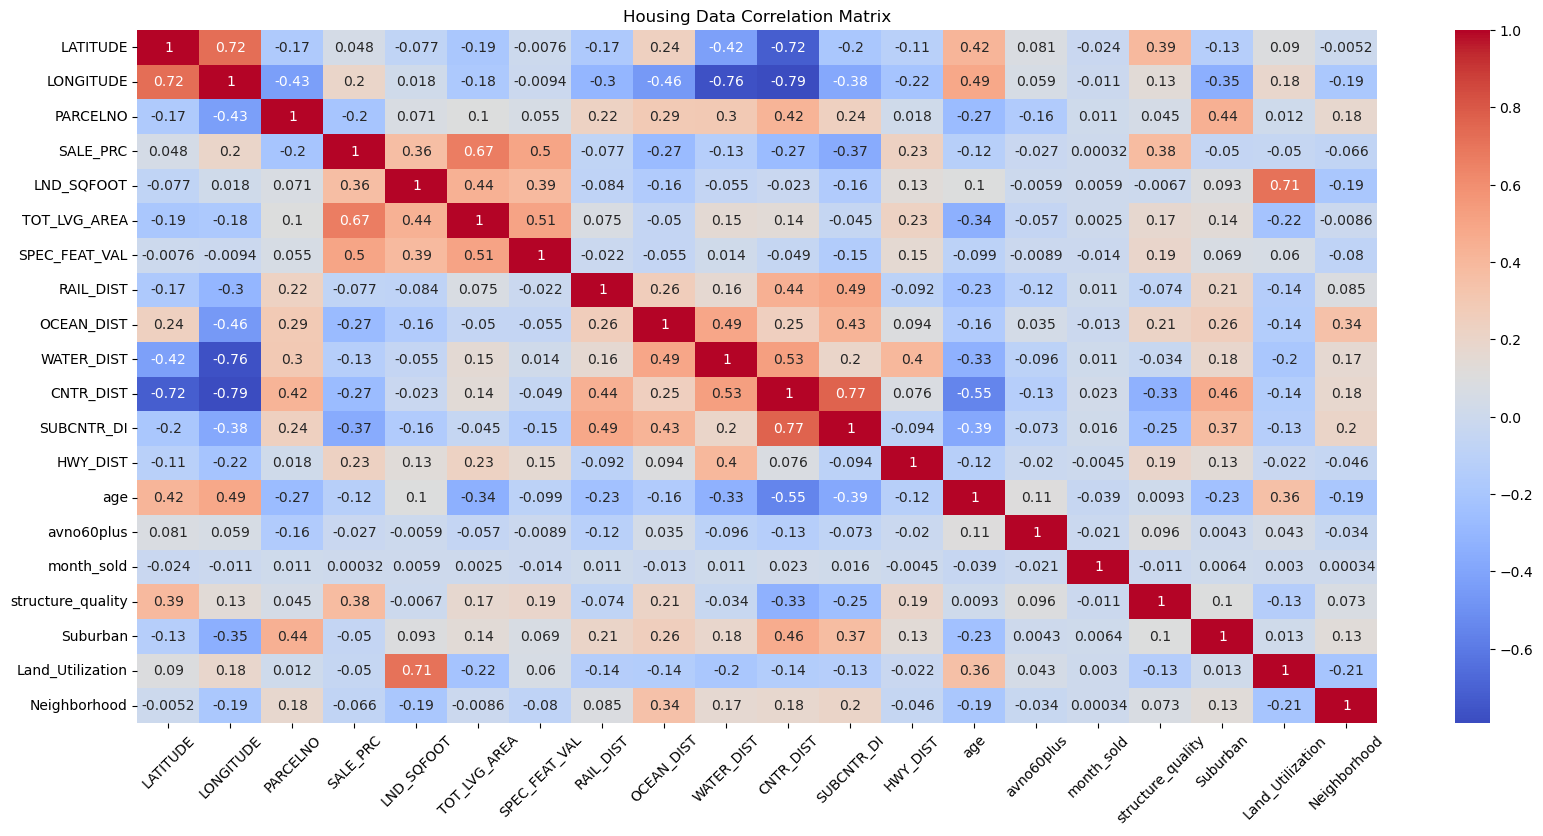

In [18]:
correlation_matrix = df.corr()

plt.figure(figsize = (20, 9))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.title('Housing Data Correlation Matrix')
plt.xticks(rotation = 45)
plt.show()

Multicollinearity
- There are several collinear features
- Latitude and Longitude are highly correlated with eachother and several other features
    - Being that these are geographic features, they are naturally going to be correlated with other geographic features
    - May be worth expirementing with removing these features, especially being that we clustered neighborhoods

Significant Features
- The most influential predictors for sale price are total living area, land size, distance to the city center, and structure quality.
- Distance-related variables and age of the property provide additional context but do not have as strong of an influence.
- Variables like rail distance and month sold are not significant factors for predicting sale price.

In [19]:
df.describe()   

,LATITUDE,LONGITUDE,PARCELNO,SALE_PRC,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality,Suburban,Land_Utilization,Neighborhood
count,13932.000000,13932.000000,1.393200e+04,1.393200e+04,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000,13932.000000
mean,25.728811,-80.327475,2.356496e+12,3.999419e+05,8620.879917,2058.044574,9562.493468,8348.548715,31690.993798,11960.285235,68490.327132,41115.047265,7723.770693,30.669251,0.014930,6.655828,3.513997,0.918246,4.405138,5.182458
std,0.140633,0.089199,1.199290e+12,3.172147e+05,6070.088742,813.538535,13890.967782,6178.027333,17595.079468,11932.992369,32008.474808,22161.825935,6068.936108,21.153068,0.121276,3.301523,1.097444,0.274000,2.500410,3.429282
min,25.434333,-80.542172,1.020008e+11,7.200000e+04,1248.000000,854.000000,0.000000,10.500000,236.100000,0.000000,3825.600000,1462.800000,90.200000,0.000000,0.000000,1.000000,1.000000,0.000000,0.839030,0.000000
25%,25.620056,-80.403278,1.079160e+12,2.350000e+05,5400.000000,1470.000000,810.000000,3299.450000,18079.350000,2675.850000,42823.100000,23996.250000,2998.125000,14.000000,0.000000,4.000000,2.000000,1.000000,2.736965,2.000000
50%,25.731810,-80.338911,3.040300e+12,3.100000e+05,7500.000000,1877.500000,2765.500000,7106.300000,28541.750000,6922.600000,65852.400000,41109.900000,6159.750000,26.000000,0.000000,7.000000,4.000000,1.000000,3.967718,5.000000
75%,25.852269,-80.258019,3.060170e+12,4.280000e+05,9126.250000,2471.000000,12352.250000,12102.600000,44310.650000,19200.000000,89358.325000,53949.375000,10854.200000,46.000000,0.000000,9.000000,4.000000,1.000000,5.454173,8.000000
max,25.974382,-80.119746,3.660170e+12,2.650000e+06,57064.000000,6287.000000,175020.000000,29621.500000,75744.900000,50399.800000,159976.500000,110553.800000,48167.300000,96.000000,1.000000,12.000000,5.000000,1.000000,46.340426,11.000000


Explain

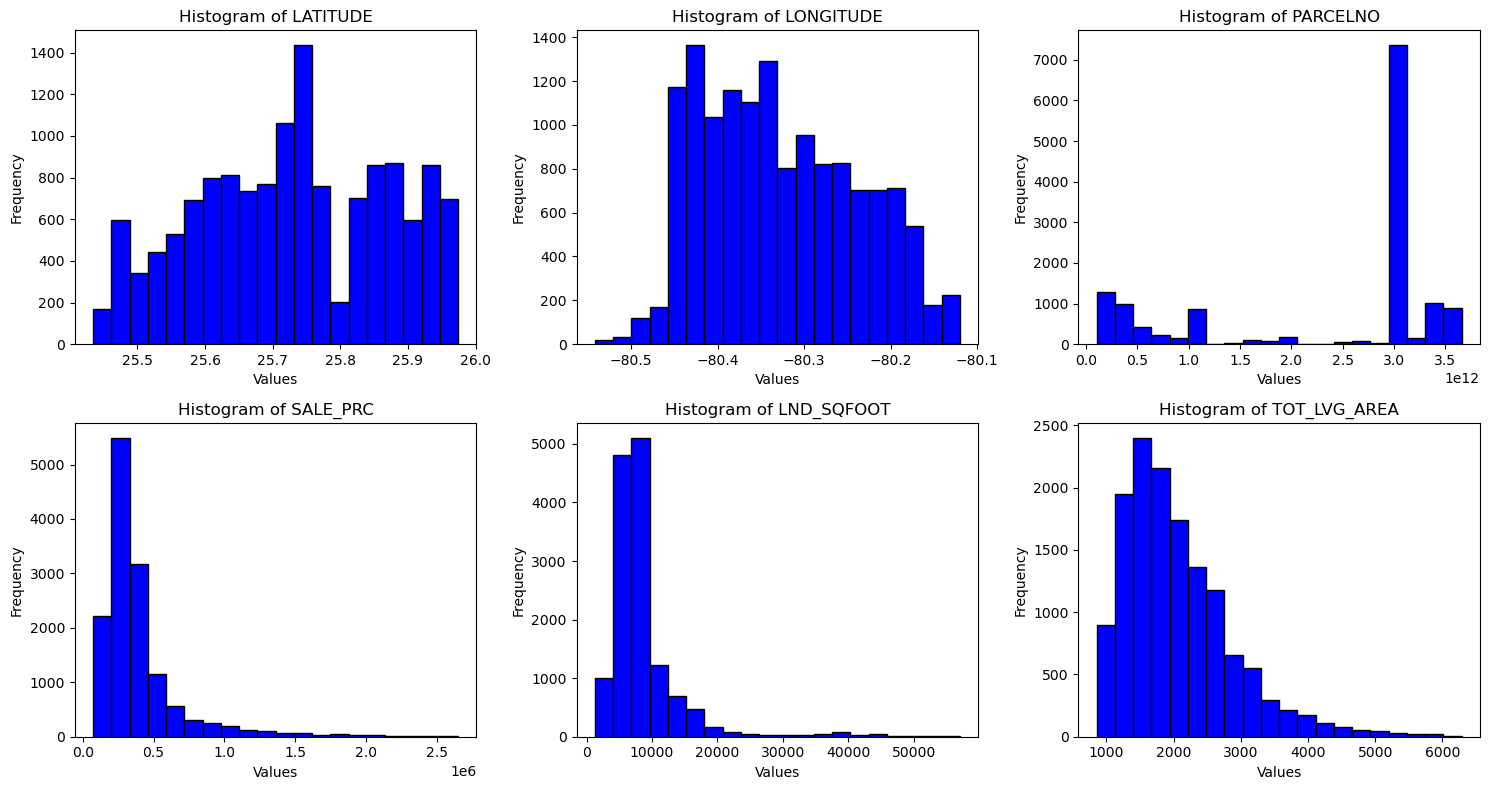

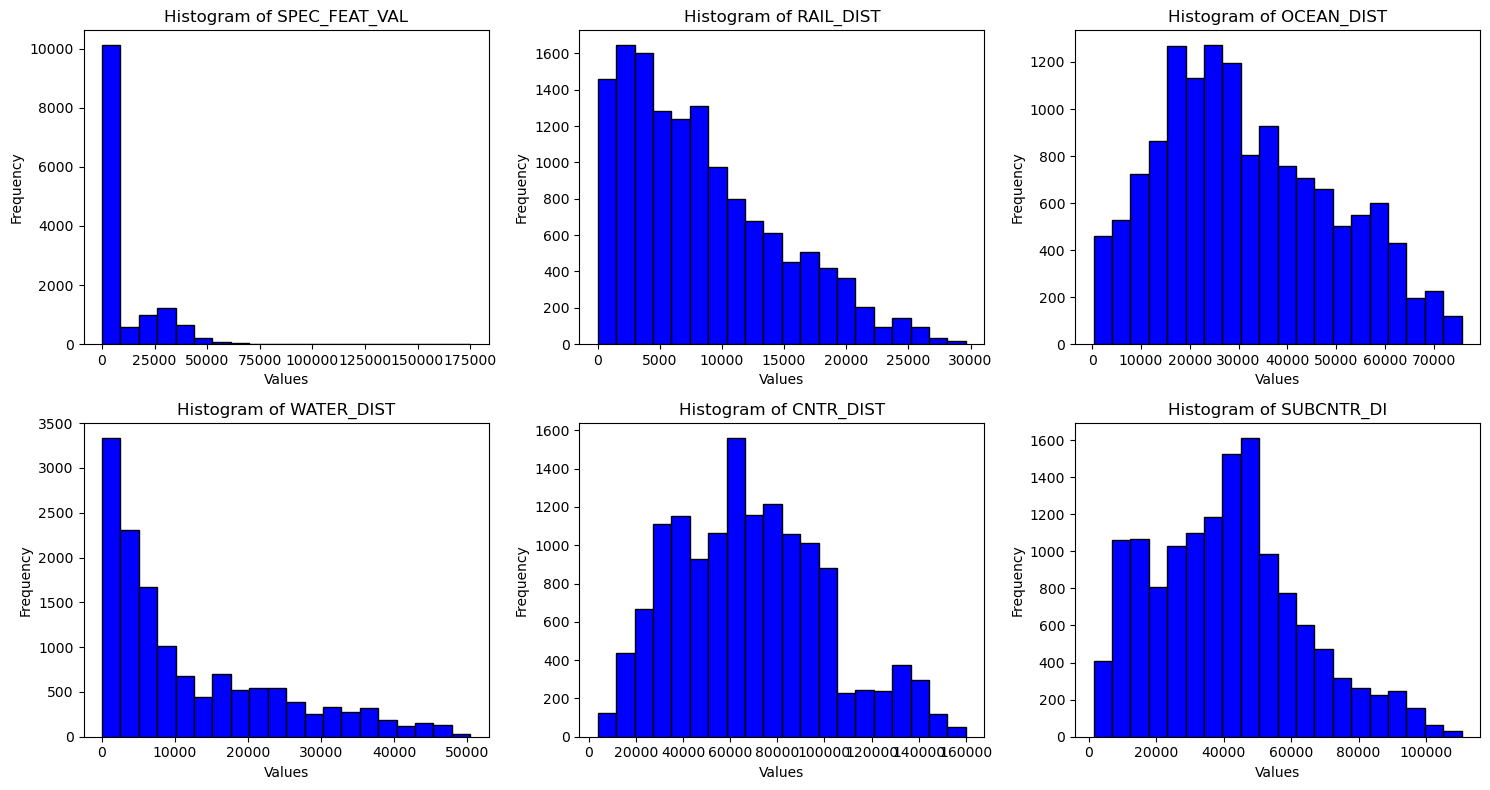

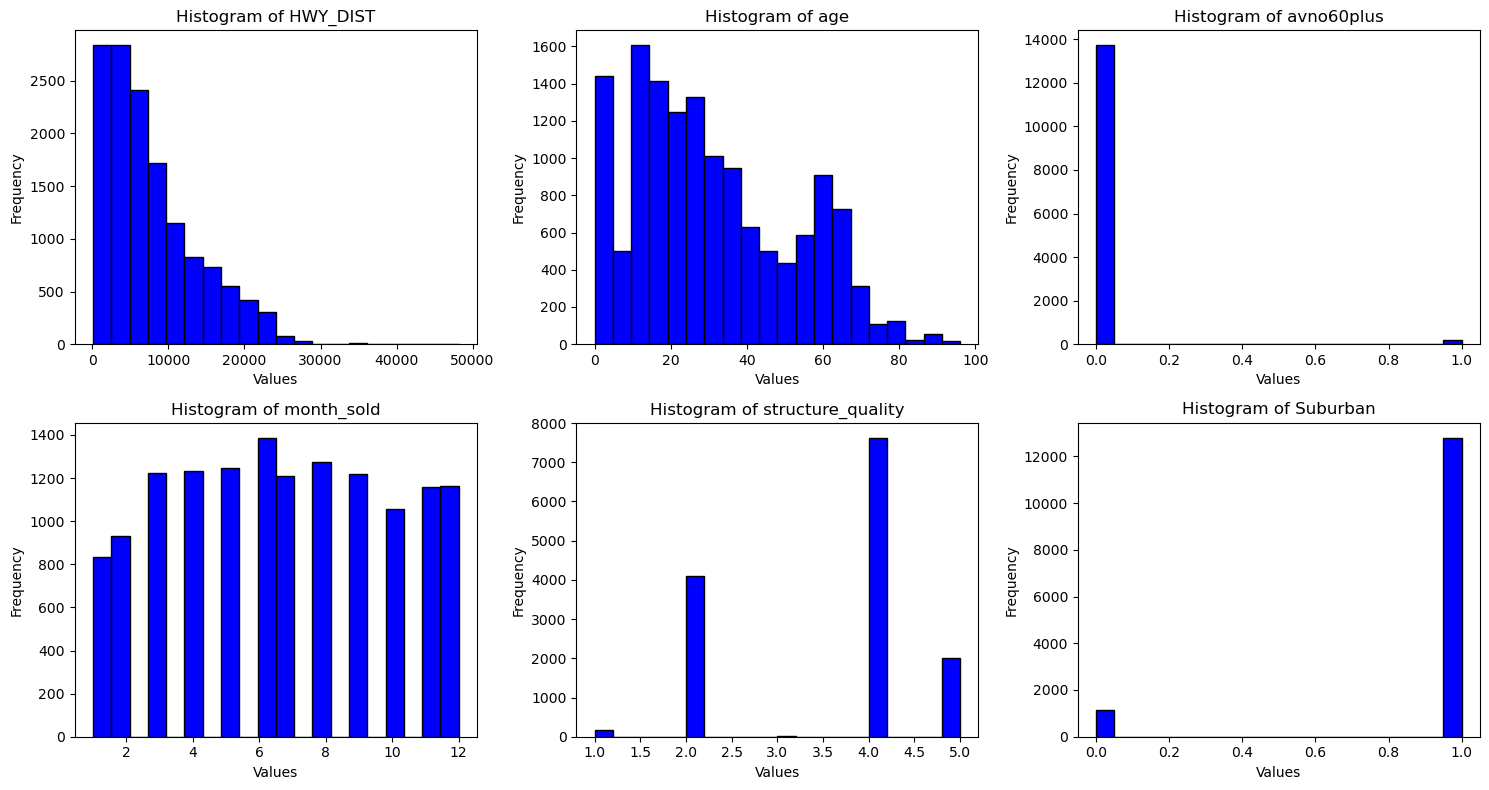

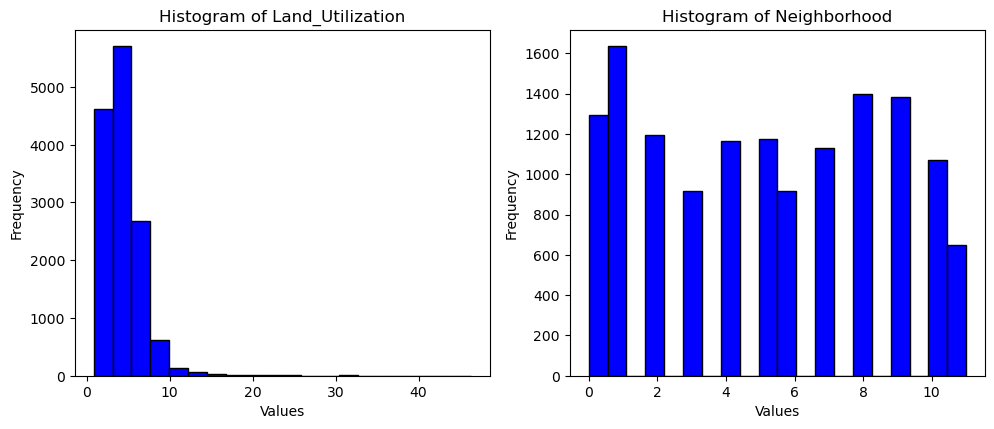

In [20]:
numeric_columns = df.select_dtypes(include='number').columns
#getting numeric columns

batch_size = 6
#defining batch size

for start in range(0, len(numeric_columns), batch_size):
    end = start + batch_size
    batch_columns = numeric_columns[start:end]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    #creating subplots
    
    for i, column in enumerate(batch_columns):
        axes[i].hist(df[column].dropna(), bins=20, color='blue', edgecolor='black')
        axes[i].set_title(f"Histogram of {column}")
        axes[i].set_ylabel("Frequency")
        axes[i].set_xlabel("Values")
    #generating histograms
    
    for i in range(len(batch_columns), len(axes)):
        fig.delaxes(axes[i])
    #removing unused axes
    
    plt.tight_layout()
    plt.show()
#plotting histograms

**Summary of Histograms**

Right-Skewed Features
- Examples: SALE_PRC, LND_SQFOOT, TOT_LVG_AREA, HWY_DIST, WATER_DIST, and SPEC_FEAT_VAL.
- Most values are clustered at the lower end with a few outliers.
- Impact: Skewed features can violate linear regression's assumption of normally distributed errors.
    - Scaling could improve model performance.

Bimodal and Spread-Out Features
- Examples: age, OCEAN_DIST, CNTR_DIST.
- These features exhibit two peaks or spread-out values.
- Impact: Non-linearity in these features may require polynomial terms or transformations to better fit the regression model.

Highly Concentrated/Sparse Features
- Examples: PARCELNO (spike at one value), avno60plus (almost all values are 0).
- Impact: Sparse or constant features provide little information and may need to be removed or one-hot encoded if categorical.

Uniform/Discrete Features
- Examples: month_sold and structure_quality.
- Uniform or categorical-like distributions can work well as dummy variables in linear regression.

Outliers
- Examples: SALE_PRC, LND_SQFOOT, TOT_LVG_AREA, and SPEC_FEAT_VAL, have notable outliers. 
- Geographic distance variables (such as RAIL_DIST, OCEAN_DIST, CNTR_DIST) also have large outliers, indicating isolated properties. 
- These outliers may skew linear models but are less problematic for tree-based models like XGBoost.
- Regularization will be employed to mitigate potential overfitting casued by these outliers.


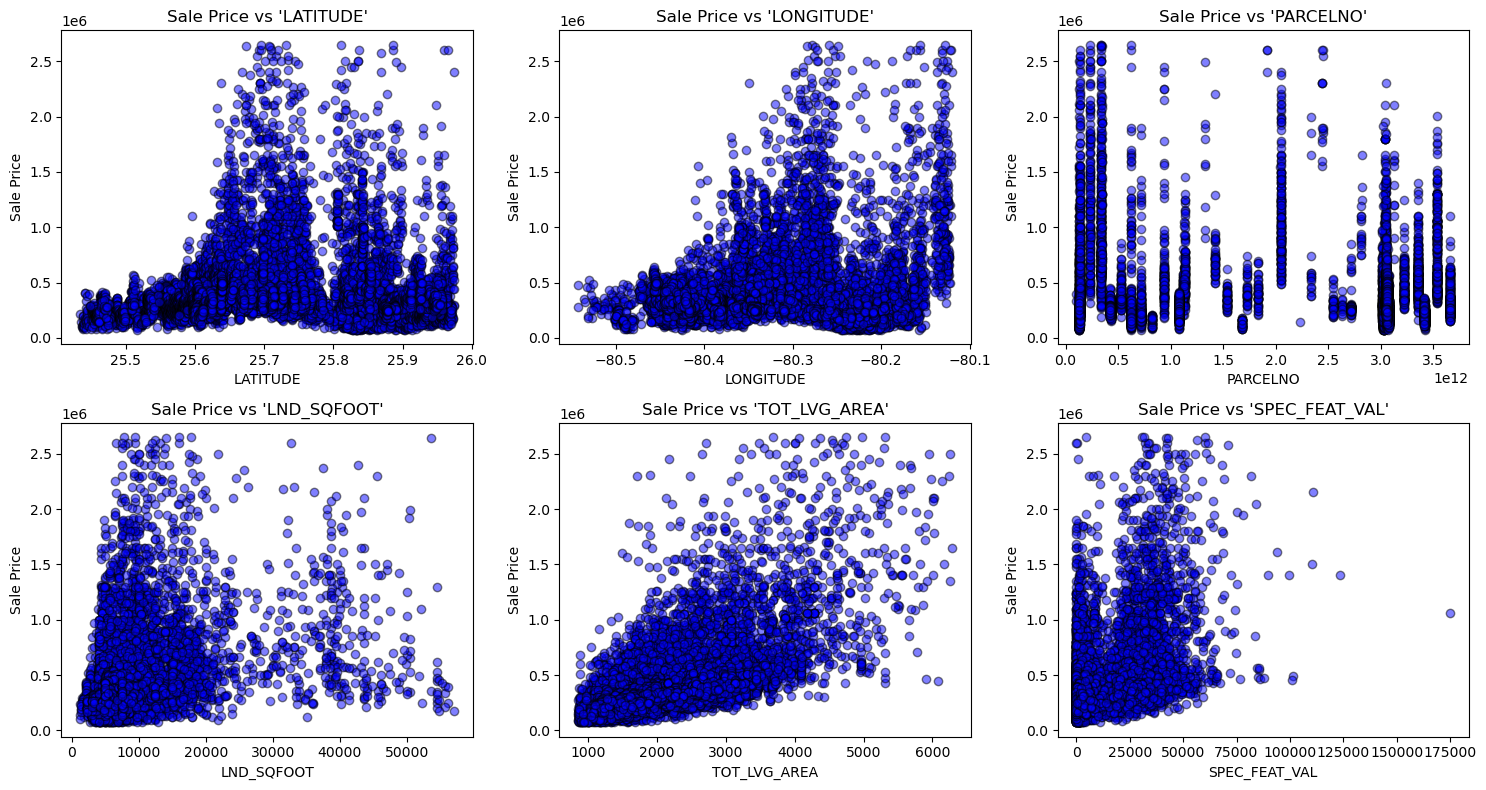

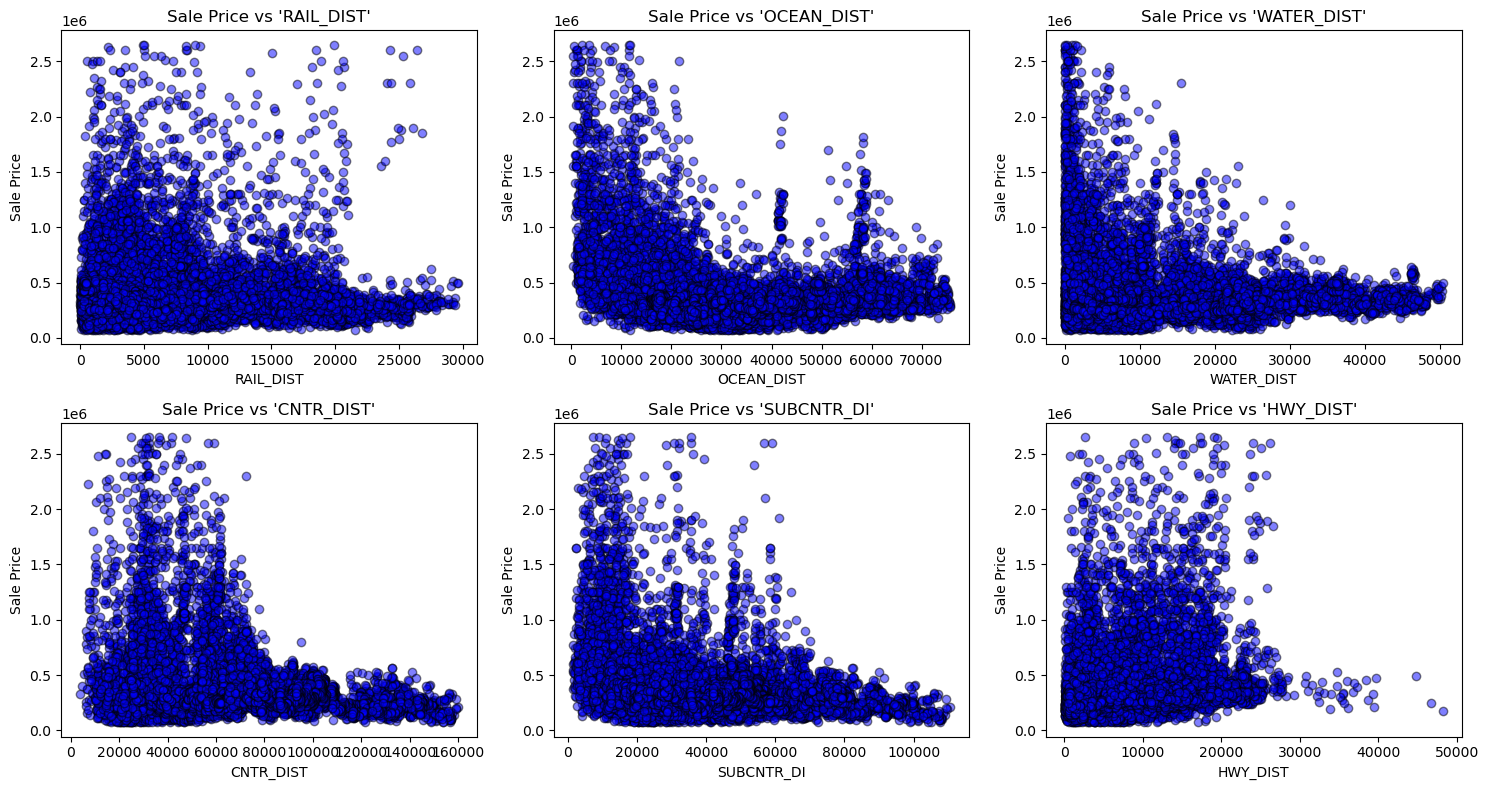

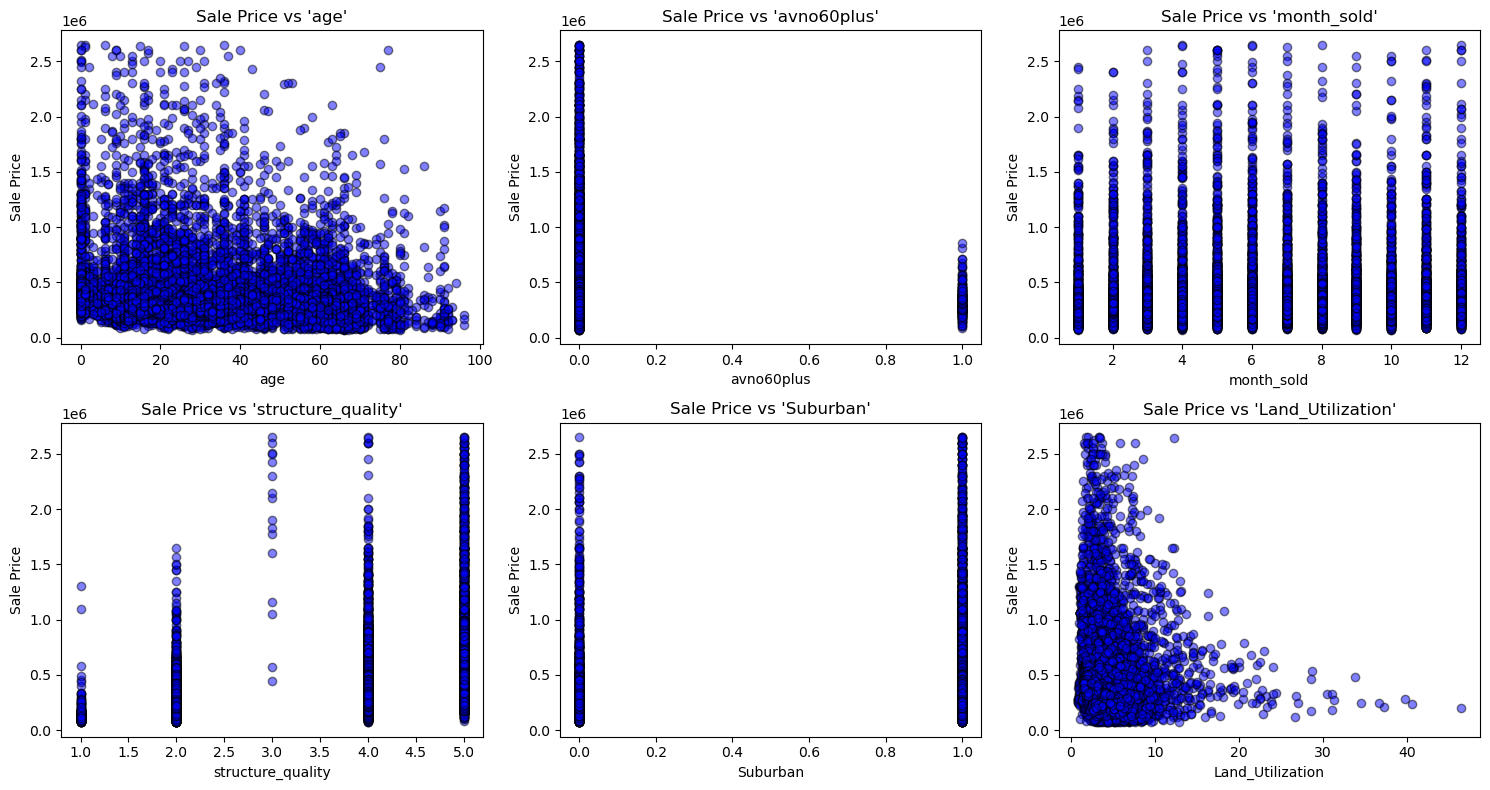

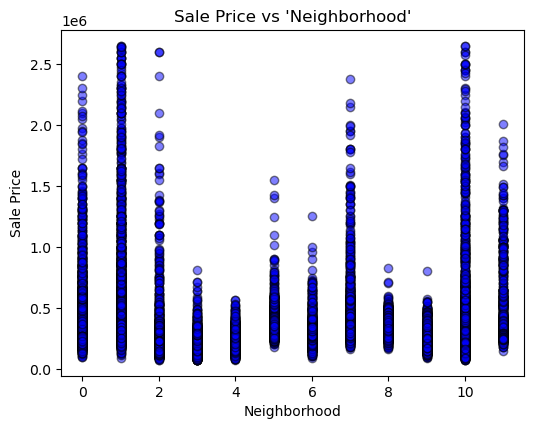

In [21]:
# Select only numeric columns, excluding 'SALE_PRC' from the list of predictors
numeric_columns = df.select_dtypes(include='number').columns
numeric_columns = numeric_columns.drop('SALE_PRC')

batch_size = 6  # Define batch size for subplots

# Plotting scatterplots between 'SALE_PRC' and the rest of the features
for start in range(0, len(numeric_columns), batch_size):
    end = start + batch_size
    batch_columns = numeric_columns[start:end]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))  #2 rows, 3 columns grid
    axes = axes.flatten()  #flattening axes for easier indexing
    
    for i, column in enumerate(batch_columns):
        axes[i].scatter(df[column], df['SALE_PRC'], alpha=0.5, color='blue', edgecolor='black')
        axes[i].set_title(f"Sale Price vs '{column}'")
        axes[i].set_xlabel(column)
        axes[i].set_ylabel("Sale Price")
        
    for i in range(len(batch_columns), len(axes)):
        fig.delaxes(axes[i])
    #remove unused axes
    
    plt.tight_layout()
    plt.show()

**Summary of Scatterplots**

- 'SLC_PRC' and 'TOTAL_LVG_AREA' has a fairly positive relationship, but is not exactly linear, which could indicate that location may be more of a significant factor
- There are not many linear relationship between the target variable and the rest of the features, violating an assumption of implementing linear regression
    - Despite this, linear regression will still be implemented in order to establish baseline metrics
    - Extreme gradient boosting could be a better option, as it could help in providing insight into some of these complex feature interactions

**Linear Regression Model**
- 

Linear regression will be used as the baseline model for this project to establish initial metrics for comparison. Although the dataset does not exhibit strong linear relationships between most features and the target variable, SALE_PRC (which violates a key assumption of linear regression), implementing this model provides a simple, interpretable starting point to gauge performance. The more advanced model, Extreme Gradient Boosting, will later account for non-linear relationships and complex feature interactions, offering improved predictive power and insights.

In [74]:
X = df.select_dtypes(include = 'number').drop(columns = ['SALE_PRC'])
y = df['SALE_PRC']
#assigning independent and dependent variables

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#train, test, split

- Train, test, split
- Allocating 80% of the dataset to train the model, 20% to test

In [75]:
linreg = LinearRegression()
#instatiating

linreg.fit(X_test, y_test)
#fitting

LinearRegression()

- Fitting the model on the training data

In [76]:
y_pred = linreg.predict(X_test)
#getting predictions

print(f'R-squared: {linreg.score(X_test, y_test)}')
print(f'Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}')

R-squared: 0.7240383223299762
Mean Absolute Error: 109610.31737014625


- R-squared of .72, meaning ~72% of the variance within the data is understood by the model
    - This is a strong value, being that there was not much linearity exhibited within the scatterplots
- Mean absolute error of ~110000, meaning that the model is off by around $110,000 on average

**Testing Linear Regression Model for Overfitting**

In [77]:
y_train_pred = linreg.predict(X_train) 
train_mae = mean_absolute_error(y_train, y_train_pred)
print("Training MAE:", train_mae)
#calculating Training Set MAE

y_test_pred = linreg.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
print("Test MAE:", test_mae)
#calculating Test Set MAE

Training MAE: 108224.10498283886
Test MAE: 109610.31737014625


Comparing the MAE of the train vs test set, to determine whether or not the model is overfitting. The MAE for the train and test set are similar, not indicating overfitting.

**Linear Regression Model Predictions**

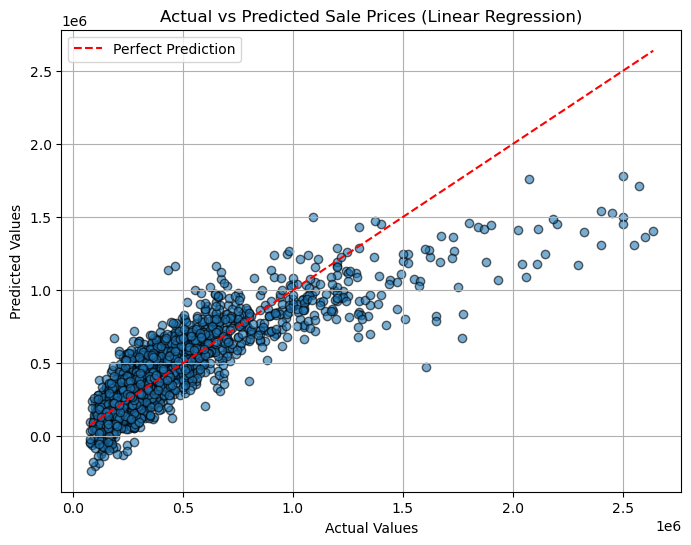

In [78]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted Sale Prices (Linear Regression)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

The scatterplot indicates that the moel is performing decent for sale prices in the lower range, but it is struggling with predicting higher sale prices accurately, often underestimating. Grid search cross validation and hyperparamter tuning will be utilized in an attempt to mitigate this.

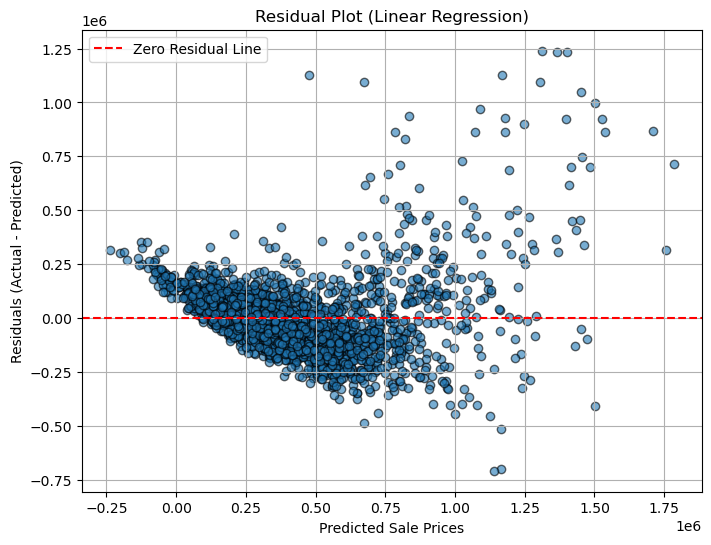

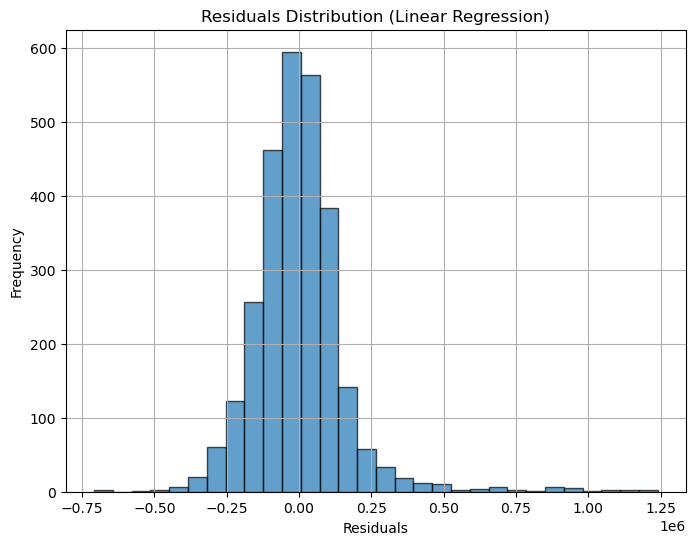

In [81]:
residuals = y_test - y_pred
#calculating residuals

#plotting residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolor='k')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual Line')
plt.title('Residual Plot (Linear Regression)')
plt.xlabel('Predicted Sale Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.show()

#residual distribution
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Residuals Distribution (Linear Regression)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Model performs well for low to mid-range predictions, indicated by the tight grouping. The funnel shape does indicate heteroscedasticity, however, which violates one of the assumptions of linear regression.

**Scaling, Using PCA, and Tuning Hyperparameters**

Experimenting with using principle component analysis, as it can help handle multicollinearity by combining correlated features into a smaller number of uncorrelated components. Several features are highly correlated (e.g.,'age'/'CNTR_DIST' and 'CNTR_DIST'/'LONGITUDE'). Also scaling, which is essential here because PCA is sensitive to feature magnitude, and the features are on vastly different scales (e.g., square footage vs. sale price).

In [82]:
estimators = [('normalise', StandardScaler()),
              ('reduce_dim', PCA()),
              ('linreg', LinearRegression())]

pipe = Pipeline(estimators)
#creating pipeline

paramGrid = {
    'reduce_dim__n_components': [0.95, 0.90, 0.85],
    'linreg__fit_intercept': [True, False] 
}
#defining parameter grid

grid = GridSearchCV(pipe, paramGrid, cv = 5, scoring = 'neg_mean_absolute_error')
#initalizing grid search cross validation

grid.fit(X_train, y_train)
linregGS = grid.best_estimator_
#fitting and setting best estimator to 'linregGS'

y_predGS = linregGS.predict(X_test)

print("Best Parameters:", grid.best_params_)
print(f'R-squared: {linregGS.score(X_test, y_test)}')
print(f'Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_predGS)}')
#printing best parameters, r-squared, and mean absolute error

Best Parameters: {'linreg__fit_intercept': True, 'reduce_dim__n_components': 0.95}
R-squared: 0.7048858635303725
Mean Absolute Error (MAE): 112354.83603774701


- Building model pipeline and hyperparameter tuning
- Using PCA and scaling
    - Using PCA can improve performance by reducing noise or redundancy in features
- Tuning PCA components and option to fit intercept

**Results**

- The model explains slightly less of the variance within the data now (.70/.71), and has a higher mean absolute error (<$110,000/$112,354)
- Potential Reasons for the higher MAE
    - Loss of Information: PCA may discard important features or relationships not captured in the top components.
    - Linear Assumptions: PCA and linear regression struggle with nonlinear relationships in the data.
    - Feature Scaling Impact: Scaling might distort meaningful relationships between features and the target variable.
    - Underfitting Risk: Reducing features with PCA can oversimplify the model.

**Linear Regression Model Predictions (PCA/Scaling/Hyperparameter Tuning)**

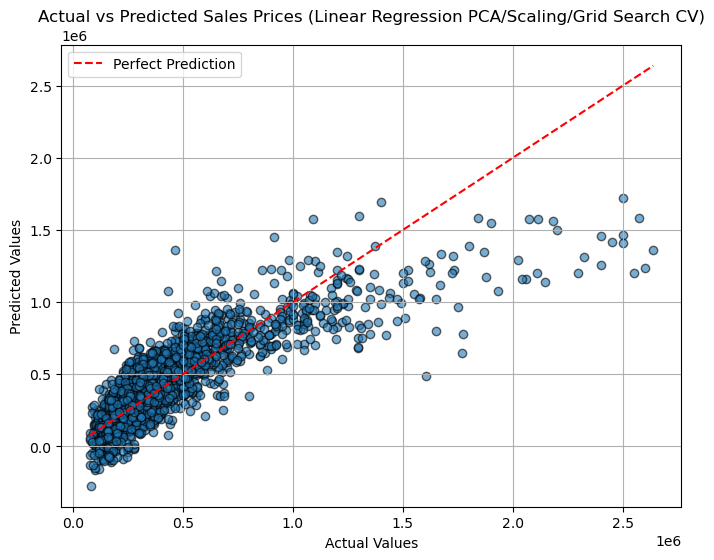

In [83]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predGS, alpha=0.6, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted Sales Prices (Linear Regression PCA/Scaling/Grid Search CV)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

**EXPLAIN**
- 

**Extreme Gradient Boosting Regression Model**
- 

Extreme Gradient Boosting will be used for advanced modeling. Extreme Gradient Boosting excels at capturing complex, nonlinear interactions between features and the target variable. It often significantly outperforms linear models, especially for structured datasets like this one, where many relationships are not linear. Extreme Gradient Boosting is highly robust in handling heteroscedasticity (which is present), ensuring better performance even when residual variance changes across predictions.

In [84]:
GBmodel = XGBRegressor(n_estimators = 100, max_depth = 6, learning_rate = 0.1, random_state = 42)
#instatiating model

GBmodel.fit(X_train, y_train)
#fitting on training data

y_predGB = GBmodel.predict(X_test)
#getting predictions

print(f'R-squared: {GBmodel.score(X_test, y_test)}')
print(f'Mean Absolute Error: {mean_absolute_error(y_test, y_predGB)}')

R-squared: 0.9185407862097623
Mean Absolute Error: 46936.742882691964


The XGBoost model significantly outperformed the baseline, achieving an R-squared of ~0.91 and an MAE of ~$47,000, cutting prediction errors by more than half. Its ability to handle complex, non-linear relationships and feature interactions allowed it to capture subtle patterns missed by linear regression. Additionally, its robustness to outliers and heteroscedasticity improved performance, especially for higher-priced properties, showcasing the effectiveness of gradient boosting in modeling the Miami housing market.

**XGBoost Model Predictions**

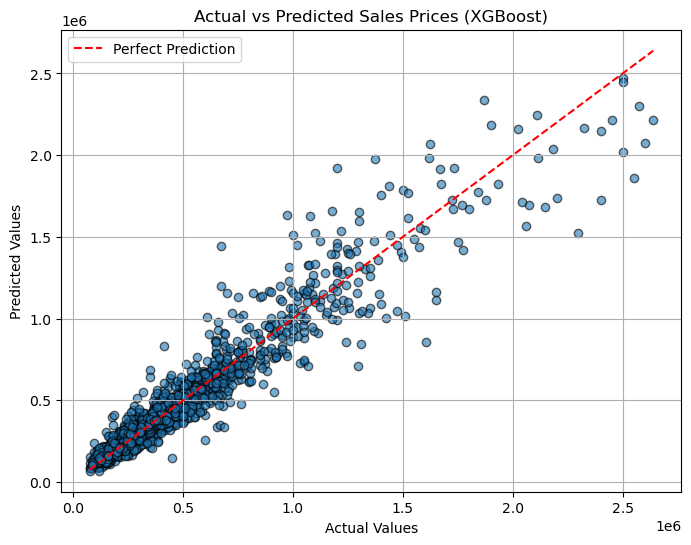

In [85]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predGB, alpha=0.6, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted Sales Prices (XGBoost)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

The predicted values closely follow the actual values, with most points falling near the diagonal line representing perfect predictions. This indicates that the XGBoost model is capturing the underlying patterns in the data well. The model performs well across a wide range of actual sale prices, including higher price ranges which linear regression struggled with. The model is often still struggling slightly with high sale prices (in comparison to the model's performance with mid to low range sale prices), but overall, there is a definite increase in performance in comparison to the baseline model.

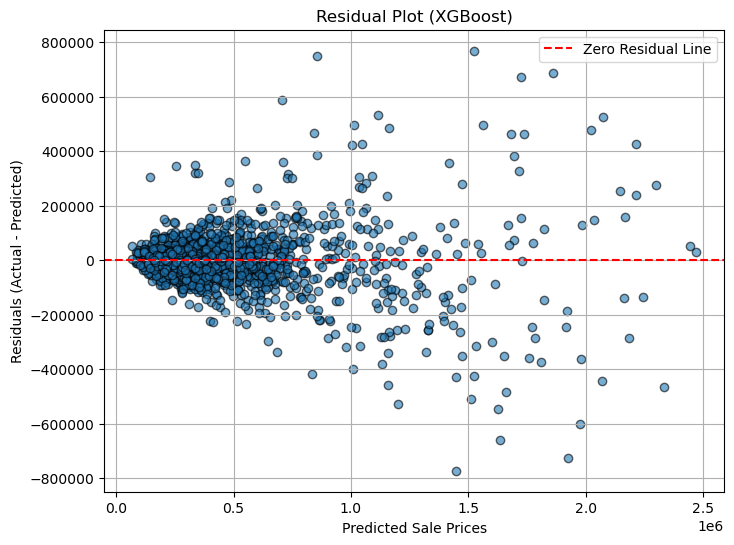

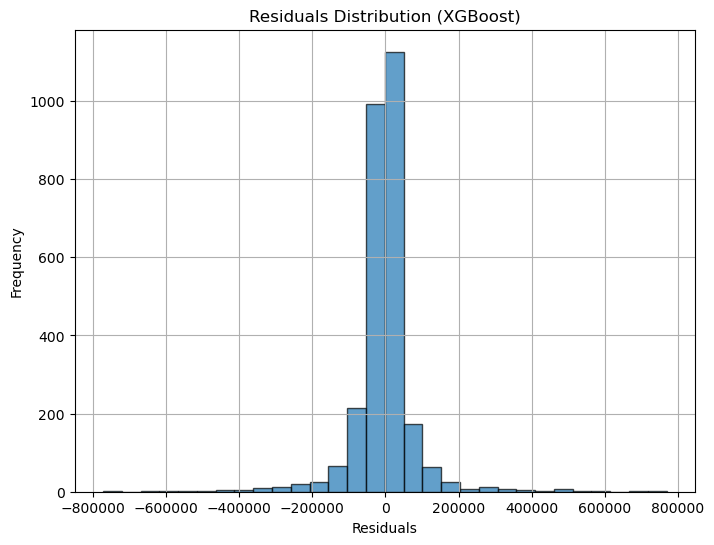

In [86]:
residuals = y_test - y_predGB
#calculating residuals

#plotting residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_predGB, residuals, alpha=0.6, edgecolor='k')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual Line')
plt.title('Residual Plot (XGBoost)')
plt.xlabel('Predicted Sale Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.show()

#residual distribution
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Residuals Distribution (XGBoost)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

The residual plot demonstrates that the errors are generally distributed around the zero line, indicating that the model captures the relationships in the data reasonably well. There is noticeable clustering of points at the lower range of predicted sale prices. This clustering suggests that the model is making more consistent predictions for lower-priced properties. As mentioned previously, the residuals exhibit greater variance as sale prices increase, which indicates that the model struggles slightly with higher-priced properties, leading to larger errors. Despite this, the residuals show no clear systematic bias, and the model performs well overall.

**Next Steps**
- 
Due to the significant computational demands of hyperparameter tuning and grid search cross-validation, I have decided not to include these steps in the current project. On my current hardware, these processes are taking an excessive amount of time, with runs exceeding 15 hours before crashing. Future iterations of this project could revisit hyperparameter tuning using more powerful computational resources or cloud-based platforms to fully optimize the model.

**Conclusion**
- 

This project analyzes Miami housing market data to predict property sale prices using machine learning models. The study begins with exploratory data analysis to understand the relationships between features, identify significant predictors, and address issues such as multicollinearity and outliers. Key features like total living area, land size, and structure quality are identified as strong predictors of sale price, while geographic features such as distance to the city center add context but are less influential.

Linear regression serves as the baseline model, providing interpretable initial metrics (R² of 0.72, MAE ~$110,000). Despite the lack of strong linear relationships between most features and the target variable, this model establishes a good benchmark for comparison. Principal Component Analysis (PCA) and scaling were also explored to handle multicollinearity, but this approach slightly reduced performance, highlighting the limitations of linear models in capturing complex, non-linear relationships in the data.

The advanced model, Extreme Gradient Boosting (XGBoost), significantly improves performance (R² of ~0.91, MAE ~$47,000). XGBoost excels at capturing non-linear feature interactions and addressing heteroscedasticity, making it more robust for this dataset. The model performs well across a wide range of sale prices and reduces the underestimation of higher-priced properties observed in the baseline model.

Overall, the XGBoost model's ability to account for complex relationships provides actionable insights into the Miami housing market, such as identifying key factors that influence property values. These insights can help real estate professionals optimize pricing strategies, assist developers and policymakers in urban planning, and support buyers and sellers in making informed decisions. The project highlights the value of combining exploratory data analysis with advanced machine learning techniques to navigate complex real estate markets effectively.